# ***Data Analysis Practice***

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

In [3]:
df = pd.read_csv('penguins.csv')

In [4]:
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [5]:
df.shape

print(f"Total potential features :{df.shape[1]}")
print(f"Total sample data :{df.shape[0]}")

Total potential features :7
Total sample data :344


In [6]:
df.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
292,Gentoo,Biscoe,48.2,15.6,221.0,5100.0,MALE
95,Adelie,Dream,40.8,18.9,208.0,4300.0,MALE
330,Gentoo,Biscoe,50.5,15.2,216.0,5000.0,FEMALE
137,Adelie,Dream,40.2,20.1,200.0,3975.0,MALE
165,Chinstrap,Dream,52.0,18.1,201.0,4050.0,MALE
317,Gentoo,Biscoe,46.9,14.6,222.0,4875.0,FEMALE
120,Adelie,Torgersen,36.2,17.2,187.0,3150.0,FEMALE
33,Adelie,Dream,40.9,18.9,184.0,3900.0,MALE
118,Adelie,Torgersen,35.7,17.0,189.0,3350.0,FEMALE
45,Adelie,Dream,39.6,18.8,190.0,4600.0,MALE


# ***Feature Screening***

In [7]:
df.isnull().sum()
#so there are some null values in our dataset. We have to handle them before training our model.

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
df.duplicated().sum()
#so there is no duplicated data in our dataset.

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

# ***Statistical Profiles***

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [11]:
count_sex = df['sex'].value_counts()
print(count_sex)

sex
MALE      168
FEMALE    165
Name: count, dtype: int64


In [12]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### ***5. Univariate Analysis( Categorical Value Analysis -1 )***

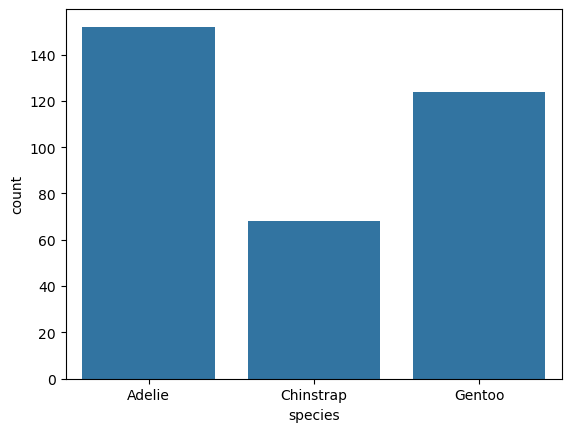

In [13]:
sns.countplot(data=df, x=df['species'])

plt.show()

In [14]:
(df['species'].value_counts()/len(df))*100

species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: count, dtype: float64

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
339    False
340    False
341    False
342    False
343    False
Length: 344, dtype: bool

In [16]:
max_body_mass = df['body_mass_g'].max()
print(max_body_mass)

6300.0


In [17]:
avg_body_mass = df['body_mass_g'].mean()
print(f"Average Body Mass: {avg_body_mass:.2f}")

Average Body Mass: 4201.75


# ***Visualization***

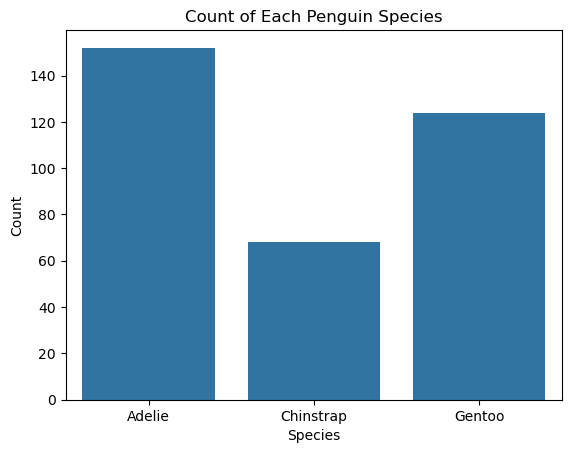

Adelie penguins are the most common species in the dataset


In [18]:
sns.countplot(data=df, x='species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Count of Each Penguin Species')
plt.show()
print("Adelie penguins are the most common species in the dataset")

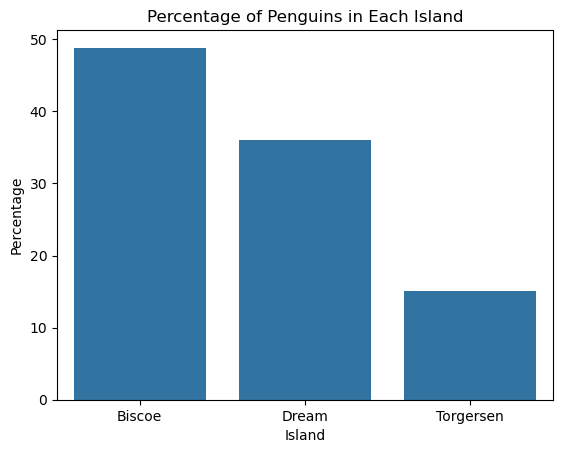

In [19]:
Penguins_percentage_in_island = (df['island'].value_counts()/len(df))*100
sns.barplot(x=Penguins_percentage_in_island.index, y=Penguins_percentage_in_island.values)
plt.xlabel('Island')
plt.ylabel('Percentage')
plt.title('Percentage of Penguins in Each Island')
plt.show()

In [20]:
df['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

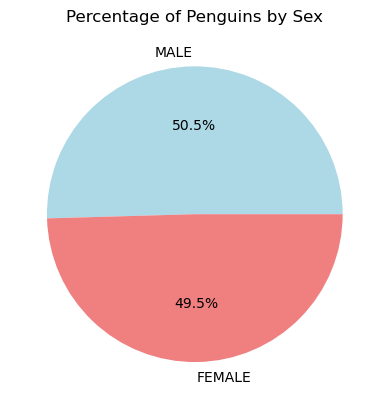

In [21]:
sex_percentage = (df['sex'].value_counts()/len(df))*100
plt.pie(sex_percentage.values, labels=sex_percentage.index, autopct='%1.1f%%',colors=['lightblue', 'lightcoral'])
plt.title('Percentage of Penguins by Sex')
plt.show()

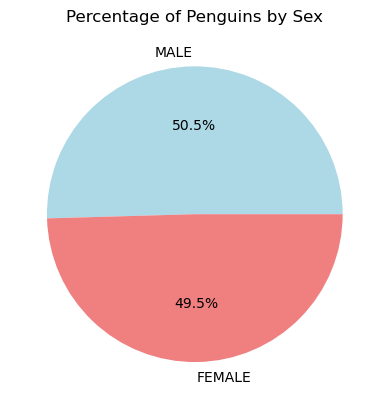

In [22]:
sex_count = df['sex'].value_counts()
plt.pie(sex_count.values, labels=sex_count.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Percentage of Penguins by Sex')
plt.show()

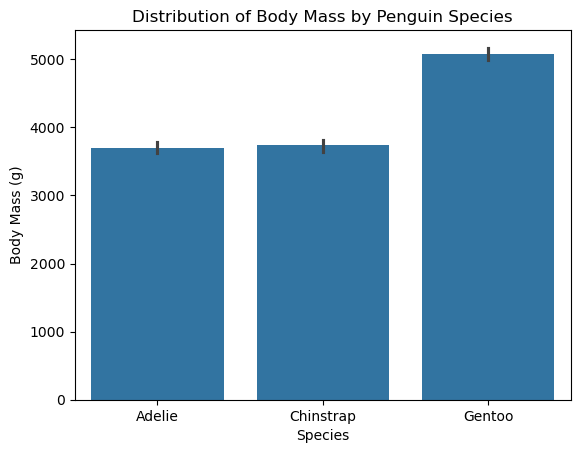

In [23]:
# shoqwing the distribution of body mass for each species
sns.barplot(x='species', y='body_mass_g', data=df)
plt.title('Distribution of Body Mass by Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

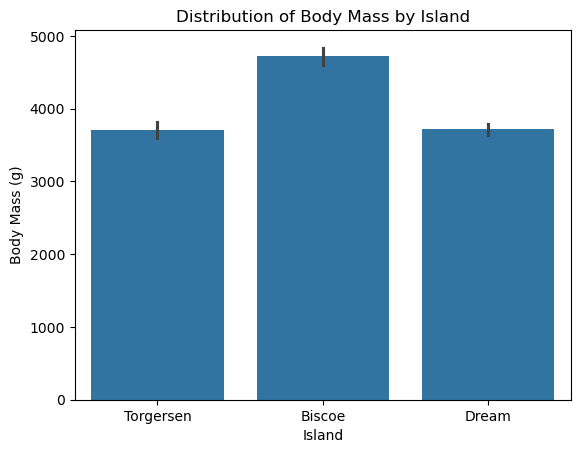

In [24]:
# showing the distribution of body mass for each island
sns.barplot(x='island', y='body_mass_g', data=df)
plt.title('Distribution of Body Mass by Island')
plt.xlabel('Island')
plt.ylabel('Body Mass (g)')
plt.show()